
### Background


I chose this topic (News Articles) because I feel that large language models (LLMs) are starting to replace aspects of human creativity. In the context of news, content generation has become faster than ever. Journalists can now cover more topics in less time, often focusing more on research and information gathering rather than the actual writing process.

While this has clear benefits, it also raises a concern. If a large portion of news content is generated using LLMs, there is a risk that articles across different platforms may start to look and feel very similar that following the same structure, tone, and patterns. This could reduce the diversity and uniqueness that typically comes from human writing.

Because of this, I found it interesting to explore whether a model can actually distinguish between human-written and machine-generated content based on writing style and language patterns.

In addition to this, I decided to build the model for both English and Nepali languages. This allows me to test whether the differences between human and AI-generated text are consistent across languages, and the algorithms / tooklikts are optimized for the multilanguages or not while also making also makes the project more relevant in a Nepali context, where such work is still relatively limited.


# Part 1: Data Collection and Cleaning

#### a) Data Collection

To build the model, I needed a good amount of data from both human-written and machine-generated sources.

##### Human-Generated Data

For the human-generated part, I built a custom web crawler using Selenium to scrape full news articles from:

https://english.onlinekhabar.com/
https://kathmandupost.com/national

I chose multiple sources to bring in some variety in writing styles and avoid relying on just one type of language. Also, to make sure the data was genuinely human-written, I only collected articles from before 2022, since LLM-generated content only started becoming common in Nepal around 2023.

In total, I collected 3000 English news articles. I specifically scraped full articles instead of headlines because headlines don’t really capture the full meaning or structure of the language.

At first, I tried truncating the articles to 5 sentences before sending them to the LLM, but that created a problem. The model started associating shorter text with human-written content, which introduced bias. So I changed the approach and only applied truncation after generating the machine data, keeping things consistent.


##### Machine-Generated Data

To generate machine-written data, I randomly split the collected dataset into two equal parts:

1500 articles kept as human-generated
1500 used to generate machine-written versions

This helped keep the dataset balanced and avoid class bias.For generating the machine outputs, I wrote a Python script using the Groq API with the llama-3.3-70b-versatile model.To make the machine-generated data more diverse (and not all look the same), I divided the 1500 articles into three groups of 500 and used different prompts for each:

##### Rephrasing

Prompt: “Rephrase this article” : Keeps the meaning but changes the wording

##### Summarization

Prompt: “Summarize this article in 5 sentences” : Produces shorter, more structured content

##### Multi-step generation

Step 1: “List the key facts from this article as bullet points”
Step 2: “Write a new 5-sentence news story based on these facts”
This creates more variation in structure and style

##### Summarization Prompt
“Summarize this article in 5 sentences” : Produces concise, information-dense outputs

##### Multi-Step Generation Prompt

Step 1: “List the key facts from this article as bullet points”
Step 2: “Write a new 5-sentence news story based on these facts”
Encourages structural and semantic transformation

##### Nepali Dataset

A similar process was followed for the Nepali language dataset, ensuring consistency in methodology across languages.



##### SCRAPPER CODE

The scapper is built to extract data from the two news site onlinekhabar and Kathmandupost. The scrapping is done in two parts. First, scrapping the news headline and storing in file. Second getting the actual news from the news link stored in the file.

In [1]:
import time

from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

# Creating options for the Chrome browser
options = Options()


# Updating preferences to make our scraping faster
prefs = {
    "profile.managed_default_content_settings.images": 2,  # Disable images to speed up loading
    "profile.managed_default_content_settings.stylesheets": 2,  # Disable CSS to avoid unnecessary rendering
}
options.add_experimental_option("prefs", prefs)

# Additional options to streamline the browser experience
options.add_argument("--disable-extensions")  # Turn off browser extensions
options.add_argument("--disable-notifications")  # Block annoying pop-ups
options.add_argument("--headless")  # Run without opening a browser window

# Initialize the Chrome WebDriver with our custom options
driver = webdriver.Chrome(options=options)


# Function to get data from online khabar
def getDataFromOnlineKhabar():
    fileNewsHeading = open("Dataset/TrainingNewsHeading.csv", 'w')
    fileNewsHeading.write('link\n')

    allNewsHeadingLink = []
    # Loop through the pages to collect headlines
    for counter in range(50, 200):  # Adjust the range based on the number of pages
        url = f'https://english.onlinekhabar.com/category/political/page/{counter}'
        driver.get(url)  # Navigate to the page
        try:
            # Wait until the news elements are present
            element = WebDriverWait(driver, 3).until(
                EC.presence_of_element_located((By.CLASS_NAME, 'listical-news-big'))
            )
        except Exception as e:
            # Handle any issues if the page doesn’t load correctly
            print(e)

        # Find and extract news headlines
        newsheadings = element.find_elements(By.CLASS_NAME, "ok-post-contents")
        for newsHeading in newsheadings:
            newsHeadingLink = newsHeading.find_element(By.TAG_NAME,"a").get_attribute("href")
            allNewsHeadingLink.append(newsHeadingLink)

            fileNewsHeading.write(f'{newsHeadingLink}\n')

    fileNewsHeading.close()

# Helper function
def extracData():
    fileOnline = open('Dataset/TrainingDataNewsOnline.csv', 'a')  # Ap
    data = pd.read_csv('Dataset/TrainingNewsHeading.csv')
    newsHeading = list(data['link'])

    for heading in newsHeading:
        getNewsDetails(heading,fileOnline)
    fileOnline.close()

# Helper Function to Extract Data From Kathmandu 
def extractKathmanduData():
    fileOnline = open('Dataset/TrainingDataNewsKathmandu.csv', 'a')
    input = pd.read_csv('Dataset/TrainingDataNewsLink.csv')
    newsHeading = list(input['link'])

    for heading in newsHeading:
        getKtmDetails(heading, fileOnline)
    fileOnline.close()

# Function to get the detailed news Kathmandu Post
def getKtmDetails(link,file):
    allOnlineNews = []
    driver.get(link)
    try:
        # Wait until the news elements are present
        element = WebDriverWait(driver, 3).until(
            EC.presence_of_element_located((By.CLASS_NAME, 'story-section'))
        )
    except Exception as e:
        # Handle any issues if the page doesn’t load correctly
        print(e)

    newsContents = element.find_elements(By.TAG_NAME,"p")
    allText = []
    for newsContent in newsContents:
        allText.append(newsContent.text.split("\n")[0].replace(",", "|"))

    newsHeadingText = " ".join(allText)
    file.write(f'{newsHeadingText}\n')

# Function to get detailed news online khabar
def getNewsDetails(link,file):
    allOnlineNews = []
    driver.get(link)
    try:
        # Wait until the news elements are present
        element = WebDriverWait(driver, 3).until(
            EC.presence_of_element_located((By.CLASS_NAME, 'post-content-wrap'))
        )
    except Exception as e:
        # Handle any issues if the page doesn’t load correctly
        print(e)

    newsContents = element.find_elements(By.TAG_NAME,"p")
    allText = []
    for newsContent in newsContents:
        allText.append(newsContent.text.split("\n")[0].replace(",", "|"))

    newsHeadingText = " ".join(allText)
    file.write(f'{newsHeadingText}\n')

# Function to get news link kathmandu post
def getDataFromKathmanduPost():
    # Opening the file to store our precious data
    file = open('Dataset/TrainingDataNewsKathmandu.csv', 'w')
    fileLink = open('Dataset/TrainingDataNewsLink.csv', 'w')
    fileLink.write('link\n')
    # Adding a header to the CSV file
    file.write('news,label\n')
    # The URL of Kathmandu Post's national news page
    url = 'https://kathmandupost.com/national'
    driver.get(url)  # Let’s navigate to the page and see what’s cooking

    allnews = []

    # Using a counter to press the “load more” button repeatedly
    # This site uses lazy loading, so more headlines appear when we click “load more”
    for counter in range(1, 50):  # Adjust the range as needed based on how many headlines you want
        try:
            # Wait until the “load more” button is visible
            element = WebDriverWait(driver, 3).until(
                EC.presence_of_element_located((By.CLASS_NAME, 'load-more-btn'))
            )
            # Click the “load more” button to fetch additional headlines
            element.click()
            print(f'Clicked “load more” {counter} times')
        except Exception as e:
            # If something goes wrong, print the error message
            print(e)
        # Wait for the page to load more content
        time.sleep(2)

    try:
        # Locate the news section on the page
        newBlock = driver.find_element(By.ID, 'news-list')
        # Find all blocks containing more news
        morenewsBlocks = newBlock.find_elements(By.CLASS_NAME, "block--morenews")
        print(f'Found {len(morenewsBlocks)} blocks of more news')

        for morenewsBlock in morenewsBlocks:
            # Extract news headlines from each block
            newsheadings = morenewsBlock.find_elements(By.CLASS_NAME, "article-image")
            for newsHeading in newsheadings:
                # Get the headline text and clean it up for our CSV file
                link = newsHeading.find_element(By.TAG_NAME, 'a').get_attribute("href")
                fileLink.write(f'{link}\n')
                # newsHeadingText = heading.split("\n")[0].replace(",", "|")
                # allnews.append(newsHeadingText)
                # # Write the headline to the CSV file
                # file.write(f'{newsHeadingText}\n')
    except Exception as e:
        # Handle any errors that occur during extraction
        print(e)
        print('Error in finding news')

    print(f'Total {len(allnews)} headlines collected')
    file.close()

# Function to get news link Online Khabar
def getDataFromOnlineKhabarNepali():
    fileNewsHeading = open("Dataset/TrainingNewsHeadingOnlineNepali.csv", 'w')
    fileNewsHeading.write('heading,link\n')

    allNewsHeadingLink = []
    # Loop through the pages to collect headlines
    for counter in range(50, 200):  # Adjust the range based on the number of pages
        url = f'https://au.onlinekhabar.com/content/news/rastiya/page/{counter}'
        driver.get(url)  # Navigate to the page
        try:
            # Wait until the news elements are present
            element = WebDriverWait(driver, 3).until(
                EC.presence_of_element_located((By.CLASS_NAME, 'ok-grid-12'))
            )
        except Exception as e:
            # Handle any issues if the page doesn’t load correctly
            print(e)

        # Find and extract news headlines
        newsheadings = element.find_elements(By.CLASS_NAME, "ok-news-post")
        for newsHeading in newsheadings:
            newsHeadingText = newsHeading.find_element(By.CLASS_NAME,"ok-news-title-txt").text
            newsHeadingLink = newsHeading.find_element(By.TAG_NAME,"a").get_attribute("href")
            allNewsHeadingLink.append(newsHeadingLink)

            fileNewsHeading.write(f'{newsHeadingText},{newsHeadingLink}\n')

    fileNewsHeading.close()

# Function to get news article
def getNewsDetailsNepali(link,file):
    allOnlineNews = []
    driver.get(link)
    try:
        # Wait until the news elements are present
        element = WebDriverWait(driver, 3).until(
            EC.presence_of_element_located((By.CLASS_NAME, 'ok18-single-post-content-wrap'))
        )
    except Exception as e:
        # Handle any issues if the page doesn’t load correctly
        print(e)

    newsContents = element.find_elements(By.TAG_NAME,"p")
    allText = []
    for newsContent in newsContents:
        allText.append(newsContent.text.split("\n")[0].replace(",", "|"))

    newsHeadingText = " ".join(allText)
    file.write(f'{newsHeadingText},0\n')
    return

# Helper Function
def extracDataNepali():
    fileOnline = open('Dataset/TrainingDataNewsOnlneNeapliContent.csv', 'a')  # Ap
    import re

    links = []

    with open("Dataset/TrainingNewsHeadingOnlineNepali.csv", "r", encoding="utf-8") as f:
        for line in f:
            # regex to extract URL
            match = re.search(r'https?://\S+', line)
            if match:
                links.append(match.group())

    # print or use
    for link in links:
        print(link)
        getNewsDetailsNepali(link,fileOnline)
        
# extracDataNepali()


There was an error managing chromedriver (error sending request for url (https://googlechromelabs.github.io/chrome-for-testing/known-good-versions-with-downloads.json)); using driver found in the cache
Error sending stats to Plausible: error sending request for url (https://plausible.io/api/event)


##### Code for Machine Generated Text Generation

The below given script using Groq with llama-3.1-8b-instant to generated news article from the prompt.

In [2]:
import pandas as pd
import time
import re
import os
from tqdm import tqdm
from groq import Groq

# Rotating multiple API keys to handle rate limits
API_KEYS = [
    # ENTER YOUR KEYS
]

MODEL             = "llama-3.1-8b-instant"
OUTPUT_CSV        = "llmGenerated/mlNepali_datasetNew.csv"
current_key_index = 0


def get_client():
    return Groq(api_key=API_KEYS[current_key_index])


def call_llm(prompt: str, retries: int = 10) -> str:
    global current_key_index

    for attempt in range(retries):
        try:
            client = get_client()
            completion = client.chat.completions.create(
                model=MODEL,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.7,
                max_completion_tokens=512,
            )
            time.sleep(0.5)
            return completion.choices[0].message.content.strip()

        except Exception as e:
            error_msg = str(e)

            if "429" in error_msg or "rate_limit_exceeded" in error_msg:
                next_index = (current_key_index + 1) % len(API_KEYS)

                if next_index == current_key_index:
                    match = re.search(r'try again in (\d+)m([\d.]+)s', error_msg)
                    if match:
                        wait = int(match.group(1)) * 60 + float(match.group(2)) + 5
                        print(f"[INFO] All keys exhausted. Waiting {wait:.0f}s...")
                        time.sleep(wait)
                    else:
                        print("[INFO] All keys exhausted. Waiting 60s...")
                        time.sleep(60)
                else:
                    print(f"[INFO] Key {current_key_index + 1} rate limited. Switching to key {next_index + 1}...")
                    current_key_index = next_index
            else:
                print(f"[WARN] Attempt {attempt + 1} failed: {e}")
                time.sleep(3)

    return ""


def write_row(row: dict):
    os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)
    file_exists = os.path.isfile(OUTPUT_CSV)
    pd.DataFrame([row]).to_csv(OUTPUT_CSV, mode='a', header=not file_exists, index=False)


# Prompt to rephrase article
def rephrase(article: str):
    output = call_llm(f"Rephrase this article. In Nepali\n\n{article}")
    write_row({"input": article, "prompt_type": "rephrase", "output": output})

# Prompt to summarize article
def summarize(article: str):
    output = call_llm(f"Summarize this article in 5 sentences. In Nepali\n\n{article}")
    write_row({"input": article, "prompt_type": "summarize", "output": output})

# Prompt to rewrite article
def rewrite(article: str):
    facts  = call_llm(f"List the key facts from this article as bullet points. In Nepali\n\n{article}")
    output = call_llm(f"Write a new 5-sentence news story based on these facts in Nepali:\n{facts}")
    write_row({"input": article, "prompt_type": "rewrite", "output": output})


def generate_ml_dataset(df: pd.DataFrame, article_col: str = "newsCleaned"):
    assert len(df) >= 698, f"Need at least 1500 rows, got {len(df)}"

    # Resume support — skip already processed rows
    already_done = 0
    if os.path.isfile(OUTPUT_CSV):
        already_done = len(pd.read_csv(OUTPUT_CSV))
        print(f"[INFO] Resuming from row {already_done}...")
    else:
        print("[INFO] Starting fresh...")

    articles = df[article_col].tolist()
    split1, split2, split3 = articles[:298], articles[298:450], articles[450:698]

    tasks = (
        [(a, "rephrase")  for a in split1] +
        [(a, "summarize") for a in split2] +
        [(a, "rewrite")   for a in split3]
    )

    # Skip already completed rows
    tasks = tasks[already_done:]
    print(f"[INFO] {len(tasks)} rows remaining...")

    for article, prompt_type in tqdm(tasks):
        if prompt_type == "rephrase":
            rephrase(article)
        elif prompt_type == "summarize":
            summarize(article)
        elif prompt_type == "rewrite":
            rewrite(article)

    print(f"\nDone! Saved to {OUTPUT_CSV}")
    print(pd.read_csv(OUTPUT_CSV)["prompt_type"].value_counts())



df = pd.read_csv("finalDataSet/prob.csv")
# Uncomment to see the working
# generate_ml_dataset(df, article_col="input")

In [3]:
import pandas as pd

In [4]:
englishDataSet = pd.read_csv('DataSetForModel/combined_english.csv')
nepaliDataSet = pd.read_csv('DataSetForModel/combined_nepali.csv')

print(f'Total Size of English Dataset {englishDataSet.shape}')
print(f'Total Size of Nepali Dataset {nepaliDataSet.shape}')

Total Size of English Dataset (2518, 2)
Total Size of Nepali Dataset (1433, 2)


#### b) Data Cleaning

For data cleaning, the following steps were performed:
##### Truncation
The news articles were truncated to 5 sentences. The idea here was to keep enough content to preserve the meaning and context, while also making sure the model isn’t overloaded with very long inputs. It also helps keep things consistent across both human and machine-generated data.

##### Noise Removal
I removed noise such as typos, unnecessary symbols, and irregular characters from the dataset. I also made sure that:
The English dataset only contains English text
The Nepali dataset only contains Nepali text

This was important because mixed or messy text could introduce unwanted patterns that the model might learn incorrectly.

##### Stopwords (Not Removed)
Even though removing stopwords is usually a standard step in NLP, I decided not to remove them for this task.

The reason is that this model is not just about understanding meaning of the text, but also about capturing how the text is written. Human writing is usually a bit messy, with filler words and inconsistent flow, whereas AI-generated text tends to be more structured, cleaner, and grammatically consistent.

If I removed stopwords, I might lose these subtle differences in writing style. So I kept them to preserve the natural structure of the text.

##### Lemmatization
I applied lemmatization to reduce words to their base (dictionary) form.

While stemming also reduces words, it often just cuts them off and can produce words that don’t really make sense. Lemmatization, on the other hand, is more context-aware and keeps the words grammatically correct.

Since my goal is to detect differences in writing style and language patterns, it made more sense to use lemmatization so that the meaning and structure of words are preserved.

#### c) Data Splitting
Finally, I split the dataset into training, validation, and test sets. I used stratified splitting to make sure that both classes (human and machine-generated) are evenly distributed across all sets.

This helps in getting a more reliable evaluation and ensures the model is tested fairly.

In [5]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')


[nltk_data] Error loading punkt: <urlopen error [Errno 8] nodename nor
[nltk_data]     servname provided, or not known>
[nltk_data] Error loading wordnet: <urlopen error [Errno 8] nodename
[nltk_data]     nor servname provided, or not known>
[nltk_data] Error loading punkt_tab: <urlopen error [Errno 8] nodename
[nltk_data]     nor servname provided, or not known>


False

In [6]:
# Setting up packages
lemmatizer = WordNetLemmatizer()

In [7]:
# English preprocessing pipeline
def preprocess_english(article):
    # 1. Removing the Noise
    article = str(article)
    article = re.sub(r'<[^>]+>', '', article)                        # remove HTML tags
    article = re.sub(r'http\S+|www\S+', '', article)                 # remove URLs
    article = re.sub(r'[^\w\s.,!?\'"-]', '', article)
    # 2. Normalization to ensure everything is lowercase
    article = article.lower().strip()
    article = re.sub(r'\d+', '', article)                            # remove numbers
    article = re.sub(r'\s+', ' ', article)                           # normalize whitespace

    # 3. Truncate to 5 sentences 
    sentences = re.split(r'(?<=[.!?])\s+', article)
    sentences = [s.strip() for s in sentences if s.strip()]
    article = ' '.join(sentences[:min(5, len(sentences))])

    # 4. Tokenization
    tokens = word_tokenize(article)

    # 5. Lemmatization
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)

In [8]:
# Nepali Preprocessing Pipeline
def preprocess_nepali(article):
    # 1. Noise Removal
    article = str(article).strip()
    article = re.sub(r'<[^>]+>', '', article)                        # remove HTML tags
    article = re.sub(r'http\S+|www\S+', '', article)                 # remove URLs
    article = re.sub(r'[^\u0900-\u097F\s।!?]', '', article)         # strip non-Devanagari

    # 2. Normalization
    article = re.sub(r'\s+', ' ', article).strip()                   # normalize whitespace

    # 3. Truncate to 5 sentences
    sentences = re.split(r'(?<=[।!?])\s*', article)
    sentences = [s.strip() for s in sentences if s.strip()]
    text = ' '.join(sentences[:min(5, len(sentences))])

    # 4. Tokenization (whitespace-based for Devanagari) as there nltk doesn't have package for nepali tokenization
    tokens = text.split()

    # 5. No lemmatization for Nepali (no reliable free library)
    return ' '.join(tokens)

In [9]:
# Mapping the function to the dataset
englishDataSet['text_clean'] = englishDataSet['text'].map(preprocess_english)
nepaliDataSet['text_clean']  = nepaliDataSet['text'].map(preprocess_nepali)

In [10]:
# Dropping the raw column from the dataset
englishDataSet.drop(columns=['text'],inplace=True)
nepaliDataSet.drop(columns=['text'],inplace=True)

#### More Cleaning
While I initially split the dataset into 1500 samples each for human-generated and machine-generated data, the generation process did not work perfectly. In several cases, the prompt failed, and instead of producing a proper output, the model simply returned text that looked very similar to the prompt itself. Also there were some failed data that were not in numpy data form but were 'nan' i.e text which was missed in null value analysis. 

I was only able to identify this issue after performing some statistical analysis on the dataset (as shown in SS). When I looked at the most frequent trigrams, phrases like “please provide the” appeared repeatedly, which clearly indicated that something was wrong with the generated outputs.

To fix this, I went back and added an additional filtering step to remove such faulty generations. This helped clean up the dataset and ensured that the machine-generated samples actually reflected meaningful content rather than prompt artifacts.
 
![A screenshot of the website](/Users/prayush/PycharmProjects/Comp8420Assignment1/preview.png)

In [11]:
def drop_nan_and_string_nan(df, name):
    before = len(df)
    df = df.dropna(subset=['text_clean'])
    df = df[df['text_clean'].str.strip().str.lower() != 'nan']
    df = df[df['text_clean'].str.strip() != '']
    df = df.reset_index(drop=True)
    print(f"{name}: {before} → {len(df)} rows (dropped {before - len(df)})")
    return df

englishDataSet = drop_nan_and_string_nan(englishDataSet, "English")
nepaliDataSet  = drop_nan_and_string_nan(nepaliDataSet,  "Nepali")

# Filter out rows where output contains prompt artefacts
artefact_patterns = r'please provide|be happy to|sentence news story|as an ai|here is a|here are|i will now'

mask = ~englishDataSet['text_clean'].str.contains(artefact_patterns, case=False, na=False)
maskNepali = ~nepaliDataSet['text_clean'].str.contains(artefact_patterns, case=False, na=False)

print(f"Removed English artefact rows : {(~mask).sum()}")
print(f"Removed Nepali artefact rows  : {(~maskNepali).sum()}")

englishDataSet = englishDataSet[mask].reset_index(drop=True)
nepaliDataSet  = nepaliDataSet[maskNepali].reset_index(drop=True)

# Drop NaN in text and text_clean
englishDataSet = englishDataSet.dropna(subset=['text_clean']).reset_index(drop=True)
nepaliDataSet = nepaliDataSet.dropna(subset=['text_clean']).reset_index(drop=True)

print(f"\nEnglish rows after cleanup : {len(englishDataSet)}")
print(f"Nepali rows after cleanup  : {len(nepaliDataSet)}")

English: 2518 → 2518 rows (dropped 0)
Nepali: 1433 → 1432 rows (dropped 1)
Removed English artefact rows : 564
Removed Nepali artefact rows  : 0

English rows after cleanup : 1954
Nepali rows after cleanup  : 1432


In [12]:
# Work on copies — original datasets untouched
english_df = englishDataSet.copy()
nepali_df  = nepaliDataSet.copy()

In [13]:
def verify_labels(df, name):
    assert set(df['label'].unique()).issubset({0, 1}), "Unexpected labels!"
    print(f"{name} Labels OK → Human(0): {(df['label']==0).sum()} | Machine(1): {(df['label']==1).sum()}")

##### Verifying the labels and class count to identify class imbalance

In [14]:
verify_labels(english_df, "English")
verify_labels(nepali_df,  "Nepali")

English Labels OK → Human(0): 1441 | Machine(1): 513
Nepali Labels OK → Human(0): 749 | Machine(1): 683


The clases here are imbalanced , while fixing the imbalance can reduce the dataset size and lose information, have a imbalanced class will introduce bias in the model so it needs to be fixed.

In [15]:
# Fixing the class imbalance 
human_en   = english_df[english_df['label'] == 0]
machine_en = english_df[english_df['label'] == 1]

human_np = nepali_df[nepali_df['label']==0]
machine_np = nepali_df[nepali_df['label']==1]

human_en_sampled  = human_en.sample(n=len(machine_en), random_state=42)
englishdf_balanced = pd.concat([human_en_sampled, machine_en]).sample(frac=1, random_state=42).reset_index(drop=True)

human_np_sampled  = human_np.sample(n=len(machine_np), random_state=42)
nepalidf_balanced = pd.concat([human_np_sampled, machine_np]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Balanced English → Human(0): {(englishdf_balanced['label']==0).sum()} | Machine(1): {(englishdf_balanced['label']==1).sum()}")
print(f"Balanced Nepali → Human(0): {(nepalidf_balanced['label']==0).sum()} | Machine(1): {(nepalidf_balanced['label']==1).sum()}")

Balanced English → Human(0): 513 | Machine(1): 513
Balanced Nepali → Human(0): 683 | Machine(1): 683


In [16]:
# Splitting the data
def split_data(df, text_col='text_clean', label_col='label'):
    train, temp = train_test_split(df, test_size=0.3, random_state=48, stratify=df[label_col])
    val, test   = train_test_split(temp, test_size=0.5, random_state=48, stratify=temp[label_col])
    print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")
    return train, val, test

In [59]:
print("=== English ===")
en_train, en_val, en_test = split_data(englishdf_balanced)

print("=== Nepali ===")
np_train, np_val, np_test = split_data(nepalidf_balanced)

=== English ===
Train: 718 | Val: 154 | Test: 154
=== Nepali ===
Train: 956 | Val: 205 | Test: 205


# Part 2 : Data Analysis and Statistical Modeling
#### a) Feature Engineering and Logistic Regression

For feature engineering, I used both TF-IDF Vectorizer and Count Vectorizer to compare the result.

For Count Vectorizer, I chose a maximum of 5000 features to capture the most frequent n-grams in the dataset. Increasing this further would include more rare phrases but also introduce sparsity, while using fewer features might miss subtle AI-generated patterns such as “in conclusion” or “in essence”.

For TF-IDF Vectorizer, I used an n-gram range of (1,4) to capture both individual words and common phrase patterns. Although using a wider range like (1,5) could potentially capture more complex writing patterns, it would also make the feature space more sparse given the size of the dataset.

For the statistical baseline, I used Logistic Regression. It is a simple and efficient model that works well with TF-IDF features and can capture linear relationships between words (or n-grams) and the target label.

In [35]:
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [31]:
def build_features(train, val, test, text_col='text_clean'):
    # One-Hot (Binary CountVectorizer)
    onehot_vec = CountVectorizer(max_features=5000, binary=True)
    X_train_oh = onehot_vec.fit_transform(train[text_col])
    X_val_oh   = onehot_vec.transform(val[text_col])
    X_test_oh  = onehot_vec.transform(test[text_col])

    # TF-IDF
    tfidf_vec  = TfidfVectorizer(max_features=5000, ngram_range=(1, 4))
    X_train_tf = tfidf_vec.fit_transform(train[text_col])
    X_val_tf   = tfidf_vec.transform(val[text_col])
    X_test_tf  = tfidf_vec.transform(test[text_col])

    return (X_train_oh, X_val_oh, X_test_oh, onehot_vec), \
           (X_train_tf, X_val_tf, X_test_tf, tfidf_vec)

## ENGLISH FEATURES
en_onehot, en_tfidf = build_features(en_train, en_val, en_test)

# NEPALI FEATURES
np_onehot, np_tfidf = build_features(np_train, np_val, np_test)

In [32]:
def train_evaluate(X_train, X_val, X_test, train_df, val_df, test_df,
                   vectorizer, feature_name, lang, label_col='label'):

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, train_df[label_col])

    # Evaluate on val and test
    for split_name, X, df in [("Val", X_val, val_df), ("Test", X_test, test_df)]:
        preds = model.predict(X)
        acc   = accuracy_score(df[label_col], preds)
        print(f"\n[{lang}] [{feature_name}] {split_name} Accuracy: {acc:.4f}")
        print(classification_report(df[label_col], preds, target_names=['Human', 'Machine']))

        # Confusion matrix
        cm = confusion_matrix(df[label_col], preds)
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Human', 'Machine'],
                    yticklabels=['Human', 'Machine'])
        plt.title(f'{lang} | {feature_name} | {split_name} Confusion Matrix')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.show()

    return model


=== English — One-Hot ===

[English] [One-Hot] Val Accuracy: 0.9026
              precision    recall  f1-score   support

       Human       0.91      0.90      0.90        77
     Machine       0.90      0.91      0.90        77

    accuracy                           0.90       154
   macro avg       0.90      0.90      0.90       154
weighted avg       0.90      0.90      0.90       154


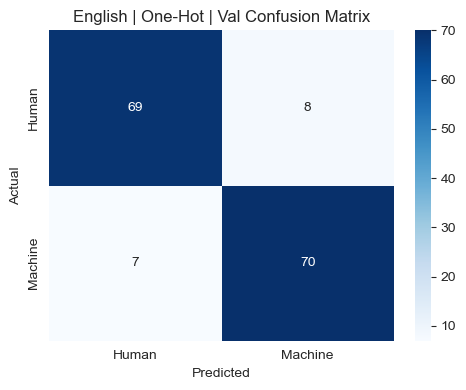


[English] [One-Hot] Test Accuracy: 0.8766
              precision    recall  f1-score   support

       Human       0.90      0.84      0.87        77
     Machine       0.85      0.91      0.88        77

    accuracy                           0.88       154
   macro avg       0.88      0.88      0.88       154
weighted avg       0.88      0.88      0.88       154


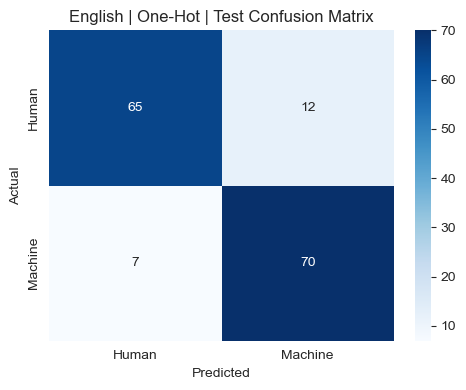


=== English — TF-IDF ===

[English] [TF-IDF] Val Accuracy: 0.8701
              precision    recall  f1-score   support

       Human       0.85      0.90      0.87        77
     Machine       0.89      0.84      0.87        77

    accuracy                           0.87       154
   macro avg       0.87      0.87      0.87       154
weighted avg       0.87      0.87      0.87       154


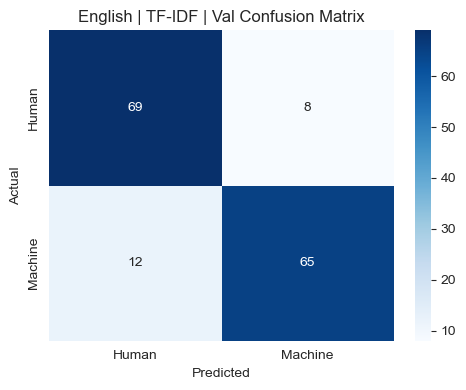


[English] [TF-IDF] Test Accuracy: 0.8506
              precision    recall  f1-score   support

       Human       0.86      0.83      0.85        77
     Machine       0.84      0.87      0.85        77

    accuracy                           0.85       154
   macro avg       0.85      0.85      0.85       154
weighted avg       0.85      0.85      0.85       154


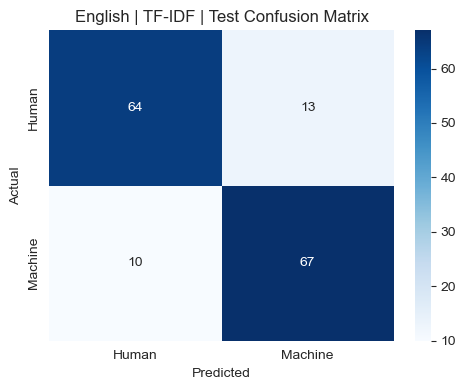


=== Nepali — One-Hot ===

[Nepali] [One-Hot] Val Accuracy: 0.5659
              precision    recall  f1-score   support

       Human       0.57      0.53      0.55       102
     Machine       0.56      0.60      0.58       103

    accuracy                           0.57       205
   macro avg       0.57      0.57      0.57       205
weighted avg       0.57      0.57      0.57       205


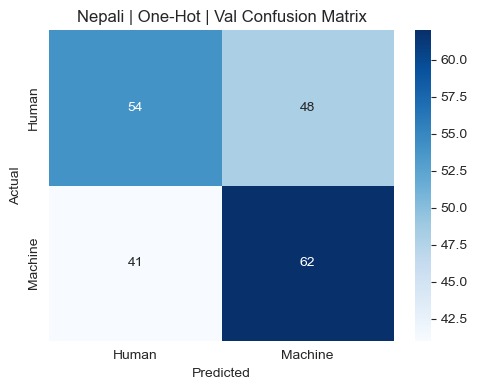


[Nepali] [One-Hot] Test Accuracy: 0.6244
              precision    recall  f1-score   support

       Human       0.64      0.58      0.61       103
     Machine       0.61      0.67      0.64       102

    accuracy                           0.62       205
   macro avg       0.63      0.62      0.62       205
weighted avg       0.63      0.62      0.62       205


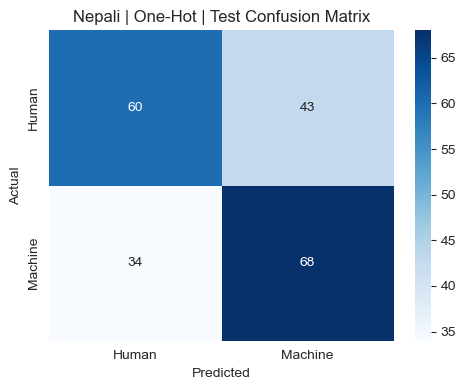


=== Nepali — TF-IDF ===

[Nepali] [TF-IDF] Val Accuracy: 0.5463
              precision    recall  f1-score   support

       Human       0.55      0.53      0.54       102
     Machine       0.55      0.56      0.56       103

    accuracy                           0.55       205
   macro avg       0.55      0.55      0.55       205
weighted avg       0.55      0.55      0.55       205


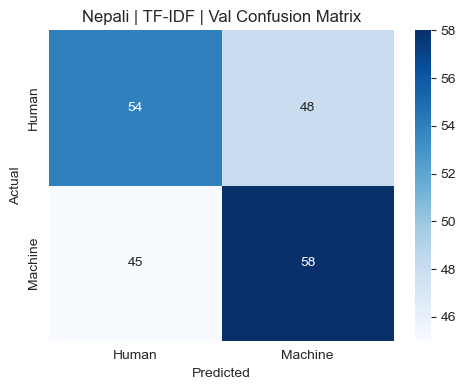


[Nepali] [TF-IDF] Test Accuracy: 0.6293
              precision    recall  f1-score   support

       Human       0.63      0.62      0.63       103
     Machine       0.62      0.64      0.63       102

    accuracy                           0.63       205
   macro avg       0.63      0.63      0.63       205
weighted avg       0.63      0.63      0.63       205


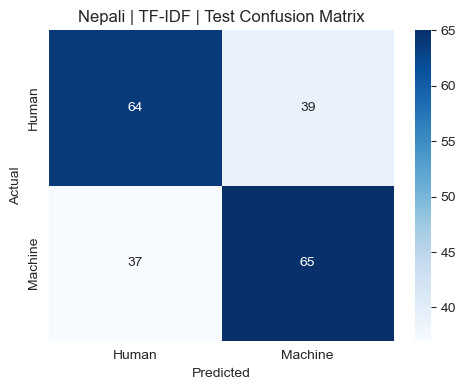

In [33]:
print("\n=== English — One-Hot ===")
en_model_oh = train_evaluate(*en_onehot[:3], en_train, en_val, en_test, en_onehot[3], "One-Hot", "English")

print("\n=== English — TF-IDF ===")
en_model_tf = train_evaluate(*en_tfidf[:3], en_train, en_val, en_test, en_tfidf[3], "TF-IDF",  "English")

print("\n=== Nepali — One-Hot ===")
np_model_oh = train_evaluate(*np_onehot[:3], np_train, np_val, np_test, np_onehot[3], "One-Hot", "Nepali")

print("\n=== Nepali — TF-IDF ===")
np_model_tf = train_evaluate(*np_tfidf[:3], np_train, np_val, np_test, np_tfidf[3],"TF-IDF",  "Nepali")

#### Statistical Analysis

From the results, the model using Count Vectorizer One Hot Encoding (accuracy: 0.8766) performs slightly than TF-IDF (accuracy: 0.85) for the English dataset when evaluated on the test set. While the difference is not huge due to the size of dataset.

This result is somewhat expected for this task. Count Vectorizer only captures whether a word or n-gram appears in the text and does not consider how frequently it appears. For AI vs human text classification, the presence of certain phrases (such as “in conclusion” or “this article discusses”) can be a strong indicator, regardless of how often they occur.

On the other hand, TF-IDF assigns lower weights to common words and higher weights to rare ones. Because of this, common stylistic phrases that are often used by AI models may get down-weighted, even though they are actually important for distinguishing machine-generated text. This can reduce the model’s ability to correctly classify such patterns.

However, for the Nepali dataset, the trend is reversed. Here, TF-IDF (accuracy: 0.6293) performs slightly better than Count Vectorizer (accuracy: 0.6244).

All in all there is no significant difference in the scores using different feature extraction technique. 

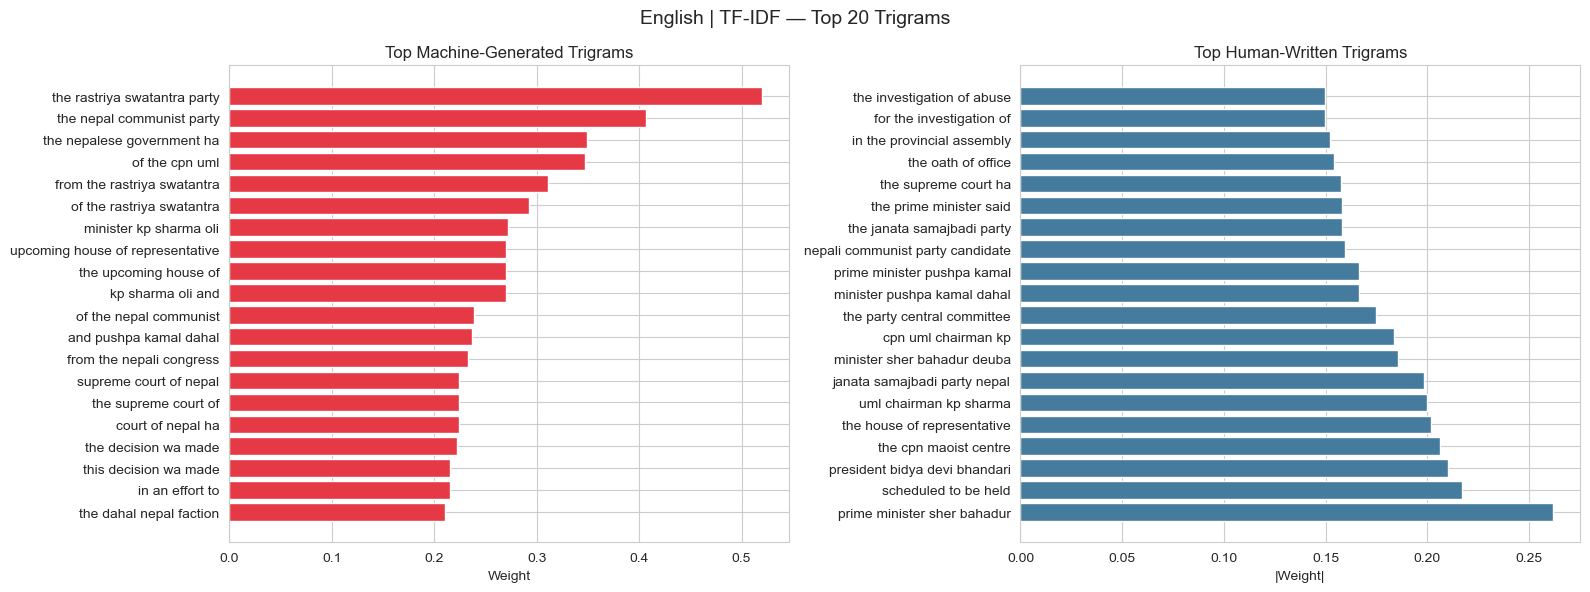

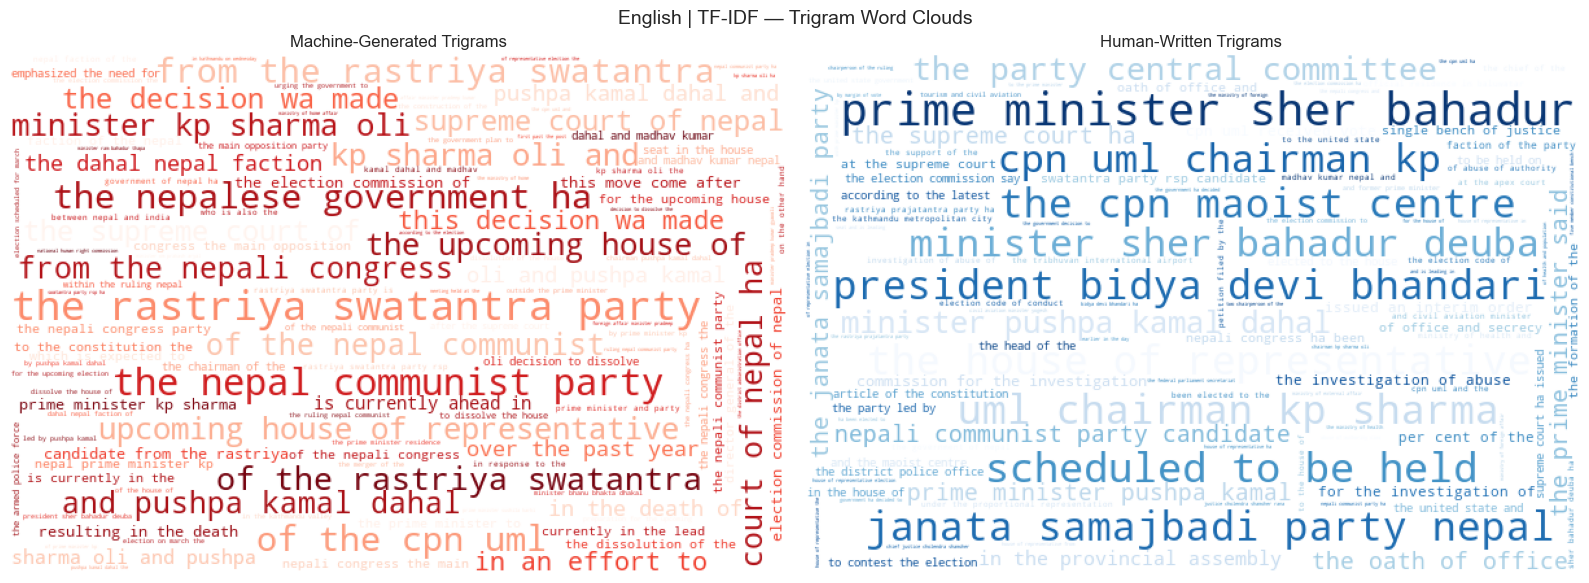

In [36]:
def plot_top_features(model, vectorizer, lang, feature_name, top_n=20):
    feature_names = vectorizer.get_feature_names_out()
    coefficients  = model.coef_[0]

    # Trigrams only — exactly 2 spaces
    mask          = np.array([f.count(' ') == 3 for f in feature_names])
    feature_names = feature_names[mask]
    coefficients  = coefficients[mask]

    top_machine = np.argsort(coefficients)[-top_n:][::-1]
    top_human   = np.argsort(coefficients)[:top_n]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'{lang} | {feature_name} — Top {top_n} Trigrams', fontsize=14)

    axes[0].barh(feature_names[top_machine][::-1], coefficients[top_machine][::-1], color='#E63946')
    axes[0].set_title('Top Machine-Generated Trigrams')
    axes[0].set_xlabel('Weight')

    axes[1].barh(feature_names[top_human], abs(coefficients[top_human]), color='#457B9D')
    axes[1].set_title('Top Human-Written Trigrams')
    axes[1].set_xlabel('|Weight|')

    plt.tight_layout()
    plt.show()


def plot_wordcloud(model, vectorizer, lang, feature_name):
    feature_names = vectorizer.get_feature_names_out()
    coefficients  = model.coef_[0]

    mask          = np.array([f.count(' ') == 3 for f in feature_names])
    feature_names = feature_names[mask]
    coefficients  = coefficients[mask]

    machine_words = {feature_names[i]: coefficients[i]
                     for i in range(len(coefficients)) if coefficients[i] > 0}
    human_words   = {feature_names[i]: abs(coefficients[i])
                     for i in range(len(coefficients)) if coefficients[i] < 0}

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'{lang} | {feature_name} — Trigram Word Clouds', fontsize=14)

    axes[0].imshow(WordCloud(width=600, height=400, background_color='white',
                             colormap='Reds').generate_from_frequencies(machine_words))
    axes[0].set_title('Machine-Generated Trigrams')
    axes[0].axis('off')

    axes[1].imshow(WordCloud(width=600, height=400, background_color='white',
                             colormap='Blues').generate_from_frequencies(human_words))
    axes[1].set_title('Human-Written Trigrams')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()


# English
plot_top_features(en_model_tf, en_tfidf[3], "English", "TF-IDF")
plot_wordcloud(en_model_tf,    en_tfidf[3], "English", "TF-IDF")

In [37]:
## Getting the top weights to understand the feature importance

def print_top_weights(model, vectorizer, lang, top_n=10):
    feature_names = vectorizer.get_feature_names_out()
    coefficients  = model.coef_[0]

    # Trigrams only
    mask          = np.array([f.count(' ') == 3 for f in feature_names])
    feature_names = feature_names[mask]
    coefficients  = coefficients[mask]

    top_machine_idx = np.argsort(coefficients)[-top_n:][::-1]
    top_human_idx   = np.argsort(coefficients)[:top_n]

    print(f"\n=== [{lang}] Top {top_n} Machine-Generated Trigrams ===")
    for i in top_machine_idx:
        print(f"  {feature_names[i]:<40} weight: {coefficients[i]:.4f}")

    print(f"\n=== [{lang}] Top {top_n} Human-Written Trigrams ===")
    for i in top_human_idx:
        print(f"  {feature_names[i]:<40} weight: {coefficients[i]:.4f}")

print_top_weights(en_model_tf, en_tfidf[3], "English")
print_top_weights(np_model_tf, np_tfidf[3], "Nepali")


=== [English] Top 10 Machine-Generated Trigrams ===
  the rastriya swatantra party             weight: 0.5201
  the nepal communist party                weight: 0.4071
  the nepalese government ha               weight: 0.3491
  of the cpn uml                           weight: 0.3469
  from the rastriya swatantra              weight: 0.3109
  of the rastriya swatantra                weight: 0.2926
  minister kp sharma oli                   weight: 0.2717
  upcoming house of representative         weight: 0.2699
  the upcoming house of                    weight: 0.2699
  kp sharma oli and                        weight: 0.2698

=== [English] Top 10 Human-Written Trigrams ===
  prime minister sher bahadur              weight: -0.2619
  scheduled to be held                     weight: -0.2171
  president bidya devi bhandari            weight: -0.2100
  the cpn maoist centre                    weight: -0.2062
  the house of representative              weight: -0.2015
  uml chairman kp sharm

From the machine-generated trigrams, many of the top features are highly structured and repetitive entity-based phrases, such as references to political parties and full formal names (e.g., “the rastriya swatantra party”, “the nepal communist party”). These phrases are grammatically clean and often follow a consistent and formal pattern, which is typical of LLM-generated text.

In contrast, human-written trigrams show slightly more variation and natural inconsistency, such as “scheduled to be help” or variations in naming (“kp sharma oli led”, “olis”). This suggests that human writing tends to include small irregularities, stylistic variation, and less rigid structure.

Another observation is that machine-generated text tends to repeat complete entity names, whereas human-written text sometimes shortens, modifies, or varies them depending on context. This difference in consistency vs flexibility becomes an important signal for classification.

For the Nepali dataset, the trigrams appear much more fragmented and less interpretable, with many tokens looking incomplete or broken. This suggests that the preprocessing (especially tokenization or encoding) may not be fully capturing meaningful word boundaries in Nepali.

Because of this, the model is likely relying on sub-word or noisy patterns rather than clear semantic phrases. This could explain why overall performance is lower compared to English.

##### Roboust Feature Engineering

Instead of using only TF-IDF or Count Vectorizer, I added custom features to capture writing style, such as average sentence length, word repetitions, and vocabulary richness. These help the model detect stylistic patterns,AI text tends to be more uniform and repetitive, while human writing is more varied—complementing the standard vectorized features.


In [38]:
# Adding custom generated features
def avg_sentence_length(text):
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]
    
    if not sentences:
        return 0
    
    word_counts = [len(s.split()) for s in sentences]
    return sum(word_counts) / len(word_counts)

from collections import Counter
def word_repetition(text):
    words = text.split()
    
    if not words:
        return 0
    
    counts = Counter(words)
    repeated = sum(c for c in counts.values() if c > 1)
    
    return repeated / len(words)

def vocab_richness(text):
    words = text.split()
    
    if not words:
        return 0
    
    unique_words = len(set(words))
    return unique_words / len(words)

In [39]:
from scipy.sparse import hstack

def build_hybrid_features(train, val, test, text_col='text_clean', max_features=5000, ngram_range=(1,4)):
    
    # TF-IDF features
    tfidf_vec = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)
    X_train_tfidf = tfidf_vec.fit_transform(train[text_col])
    X_val_tfidf   = tfidf_vec.transform(val[text_col])
    X_test_tfidf  = tfidf_vec.transform(test[text_col])
    
    # Engineered features as dense arrays
    def engineered_features(df):
        return np.array([
            [avg_sentence_length(t), word_repetition(t), vocab_richness(t)]
            for t in df[text_col]
        ])
    
    X_train_eng = engineered_features(train)
    X_val_eng   = engineered_features(val)
    X_test_eng  = engineered_features(test)
    
    # Combine TF-IDF (sparse) with engineered (dense) features
    X_train_hybrid = hstack([X_train_tfidf, X_train_eng])
    X_val_hybrid   = hstack([X_val_tfidf, X_val_eng])
    X_test_hybrid  = hstack([X_test_tfidf, X_test_eng])
    
    return (X_train_hybrid, X_val_hybrid, X_test_hybrid, tfidf_vec)

In [40]:
# English
X_en_train, X_en_val, X_en_test, en_tfidf_vec = build_hybrid_features(en_train, en_val, en_test)

# Nepali
X_np_train, X_np_val, X_np_test, np_tfidf_vec = build_hybrid_features(np_train, np_val, np_test)

In [41]:
# Training the hybrid dataset with LR Model
def train_evaluate_hybrid(X_train, X_val, X_test, train_df, val_df, test_df,
                          feature_name='Hybrid', lang='English', label_col='label'):

    # Initialize model
    model = LogisticRegression(max_iter=1000, random_state=42)
    
    # Fit model
    model.fit(X_train, train_df[label_col])
    
    # Evaluate
    for split_name, X, df in [("Val", X_val, val_df), ("Test", X_test, test_df)]:
        preds = model.predict(X)
        acc   = accuracy_score(df[label_col], preds)
        
        print(f"\n[{lang}] [{feature_name}] {split_name} Accuracy: {acc:.4f}")
        print(classification_report(df[label_col], preds, target_names=['Human', 'Machine']))
        
        # Confusion matrix
        cm = confusion_matrix(df[label_col], preds)
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Human', 'Machine'],
                    yticklabels=['Human', 'Machine'])
        plt.title(f'{lang} | {feature_name} | {split_name} Confusion Matrix')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.show()
    
    return model


[English] [TF-IDF + Engineered] Val Accuracy: 0.8571
              precision    recall  f1-score   support

       Human       0.83      0.90      0.86        77
     Machine       0.89      0.82      0.85        77

    accuracy                           0.86       154
   macro avg       0.86      0.86      0.86       154
weighted avg       0.86      0.86      0.86       154


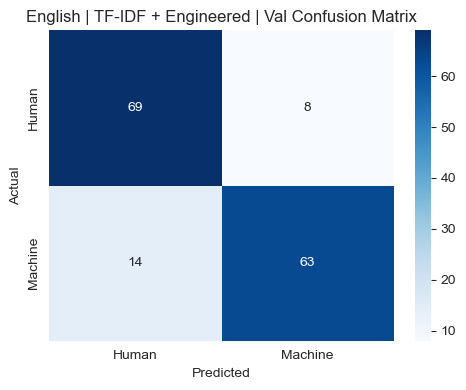


[English] [TF-IDF + Engineered] Test Accuracy: 0.8636
              precision    recall  f1-score   support

       Human       0.87      0.86      0.86        77
     Machine       0.86      0.87      0.86        77

    accuracy                           0.86       154
   macro avg       0.86      0.86      0.86       154
weighted avg       0.86      0.86      0.86       154


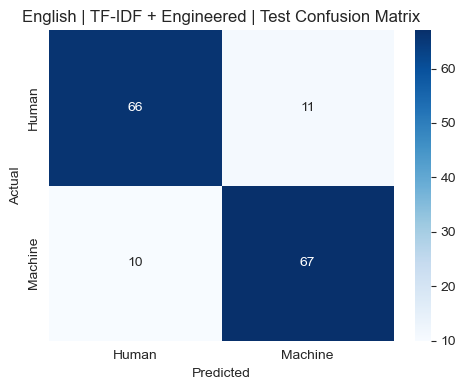


[Nepali] [TF-IDF + Engineered] Val Accuracy: 0.5610
              precision    recall  f1-score   support

       Human       0.57      0.51      0.54       102
     Machine       0.56      0.61      0.58       103

    accuracy                           0.56       205
   macro avg       0.56      0.56      0.56       205
weighted avg       0.56      0.56      0.56       205


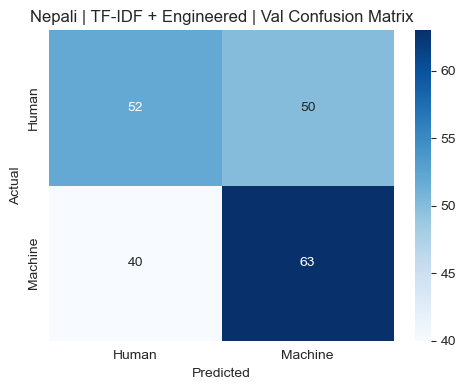


[Nepali] [TF-IDF + Engineered] Test Accuracy: 0.6390
              precision    recall  f1-score   support

       Human       0.64      0.64      0.64       103
     Machine       0.64      0.64      0.64       102

    accuracy                           0.64       205
   macro avg       0.64      0.64      0.64       205
weighted avg       0.64      0.64      0.64       205


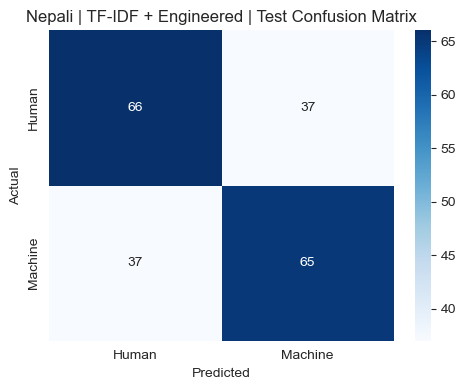

In [42]:
# English
en_modelHb = train_evaluate_hybrid(
    X_en_train, X_en_val, X_en_test,
    en_train, en_val, en_test,
    feature_name='TF-IDF + Engineered', lang='English'
)

# Nepali
np_modelHB = train_evaluate_hybrid(
    X_np_train, X_np_val, X_np_test,
    np_train, np_val, np_test,
    feature_name='TF-IDF + Engineered', lang='Nepali'
)

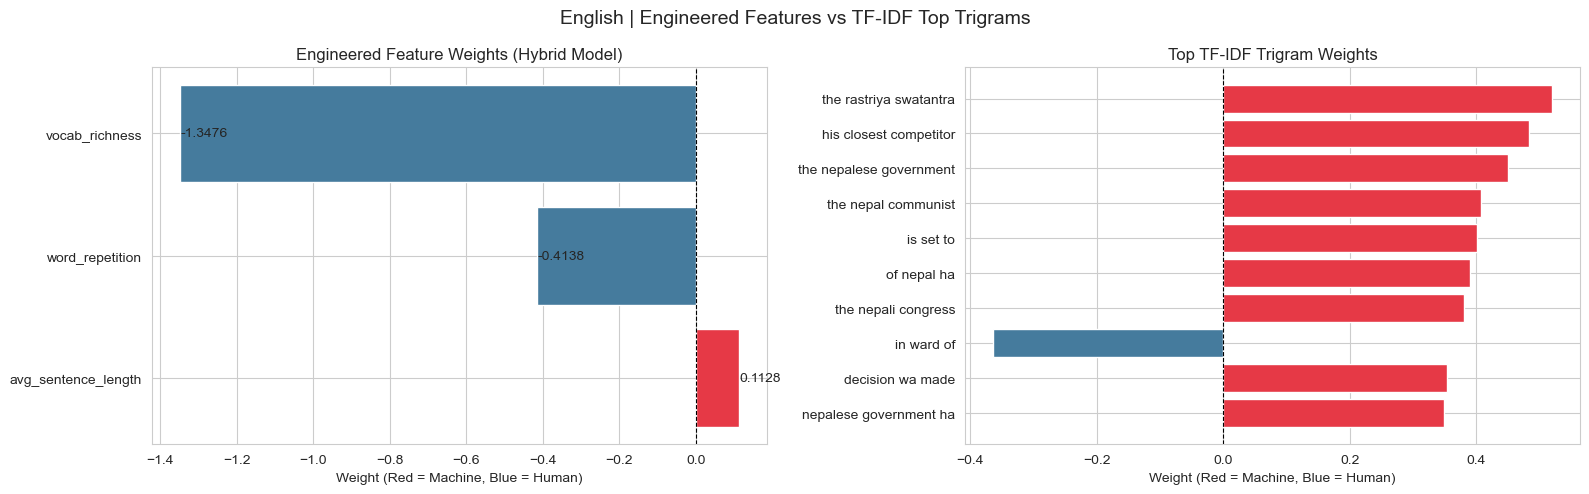

/var/folders/c1/w0s2sjpd3ms__5lz5nrj1mk00000gn/T/ipykernel_1369/487863433.py:34: UserWarning: Glyph 2310 (\N{DEVANAGARI LETTER AA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/c1/w0s2sjpd3ms__5lz5nrj1mk00000gn/T/ipykernel_1369/487863433.py:34: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/var/folders/c1/w0s2sjpd3ms__5lz5nrj1mk00000gn/T/ipykernel_1369/487863433.py:34: UserWarning: Glyph 2351 (\N{DEVANAGARI LETTER YA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/c1/w0s2sjpd3ms__5lz5nrj1mk00000gn/T/ipykernel_1369/487863433.py:34: UserWarning: Glyph 2332 (\N{DEVANAGARI LETTER JA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/c1/w0s2sjpd3ms__5lz5nrj1mk00000gn/T/ipykernel_1369/487863433.py:34: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/c1/w0s2sjpd3ms__5lz5nrj1mk00000gn/T/ipykernel_1369/487863433.py:34: UserWarning: Glyph 23

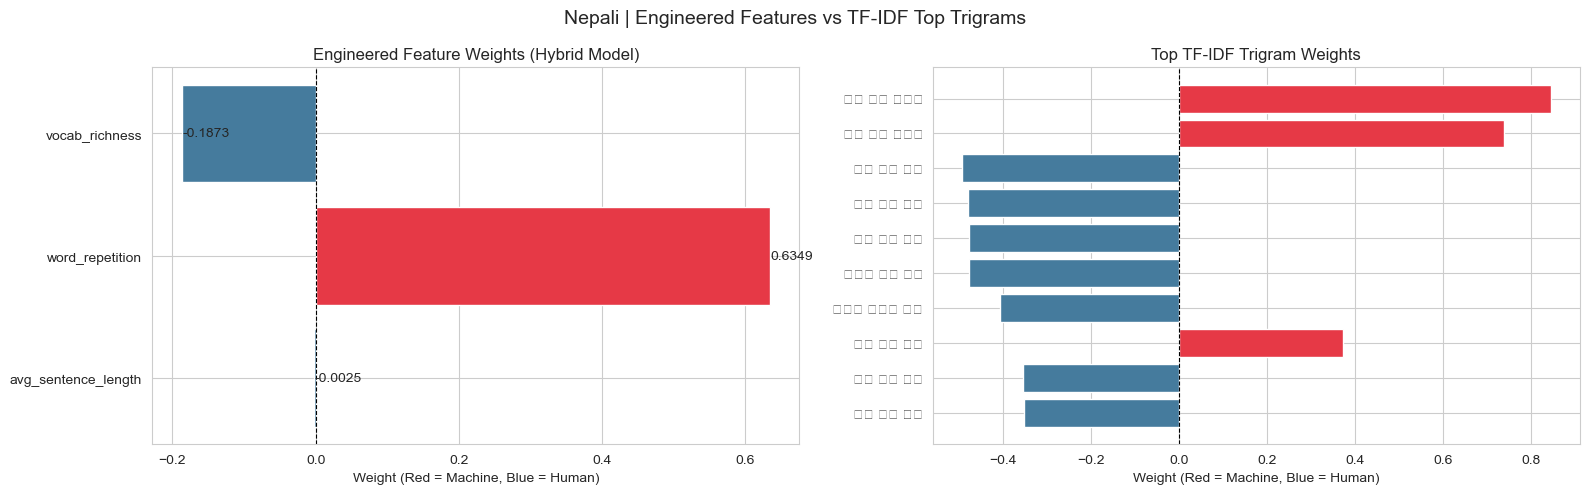

In [43]:
# Plotting the generated feature importance and TFIDF importance
def plot_engineered_vs_tfidf(model_tfidf, model_hybrid, vectorizer, lang):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'{lang} | Engineered Features vs TF-IDF Top Trigrams', fontsize=14)

    # ── Left: Engineered feature weights from Hybrid model ────────────────────
    engineered_names = ['avg_sentence_length', 'word_repetition', 'vocab_richness']
    engineered_coef  = model_hybrid.coef_[0][-3:]
    colors           = ['#E63946' if c > 0 else '#457B9D' for c in engineered_coef]

    bars = axes[0].barh(engineered_names, engineered_coef, color=colors)
    axes[0].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
    axes[0].set_title('Engineered Feature Weights (Hybrid Model)')
    axes[0].set_xlabel('Weight (Red = Machine, Blue = Human)')
    for bar, coef in zip(bars, engineered_coef):
        axes[0].text(coef + 0.001, bar.get_y() + bar.get_height()/2,
                     f'{coef:.4f}', va='center', fontsize=10)

    # ── Right: Top TF-IDF trigram weights ─────────────────────────────────────
    feature_names = vectorizer.get_feature_names_out()
    coefficients  = model_tfidf.coef_[0]
    mask          = np.array([f.count(' ') == 2 for f in feature_names])
    tri_names     = feature_names[mask]
    tri_coef      = coefficients[mask]

    top_idx  = np.argsort(np.abs(tri_coef))[-10:][::-1]
    colors2  = ['#E63946' if tri_coef[i] > 0 else '#457B9D' for i in top_idx]

    axes[1].barh(tri_names[top_idx][::-1], tri_coef[top_idx][::-1], color=colors2[::-1])
    axes[1].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
    axes[1].set_title('Top TF-IDF Trigram Weights')
    axes[1].set_xlabel('Weight (Red = Machine, Blue = Human)')

    plt.tight_layout()
    plt.show()


# English
plot_engineered_vs_tfidf(en_model_tf, en_modelHb, en_tfidf[3], "English")

# Nepali
plot_engineered_vs_tfidf(np_model_tf, np_modelHB, np_tfidf[3], "Nepali")

# Final Statistical Findings With Engineered Featured

For engineered feature in English data we can see that

Word repetition (-0.413) — human predictor. Human journalists naturally repeat key terms such as party names or people, whereas LLMs are trained to minimize repetition.

Vocabulary richness (-1.34) — strong human predictor. Journalists often use domain-specific words repeatedly, while LLMs diversify word choice more.

Average sentence length (+0.11) — weak machine predictor. LLMs tend to write slightly longer sentences, but this is a very minor signal.

For engineered feature in nepali

Word repetition (+0.6349) — strongest machine predictor. In Nepali, LLMs actually repeat sub-word patterns more than human text, likely due to tokenization artifacts and model behavior in smaller datasets.

Vocabulary richness (-0.1837) — human predictor. Similar to English, human journalists tend to reuse specific vocabulary, while LLMs diversify word choice.

Average sentence length (+0.0025) — very weak machine predictor. LLMs write slightly longer sentences, but the effect is minimal.

Finally, In English, repeating key words and phrases is a strong signal of human writing, reflecting how journalists naturally emphasize names, parties, or important terms. Interestingly, in Nepali, repetition actually points more toward machine-generated text, likely due to tokenization. Across both languages, richness of vocabulary consistently indicates human authorship, since journalists tend to reuse domain-specific words in a natural way, whereas LLMs diversify their word choice. Sentence length, on the other hand, contributes very little to distinguishing between human and machine text, as both tend to produce similarly sized sentences.

##### Changing the classifer to see if the accuracy is improved

In [44]:
import xgboost as xgb
from scipy.sparse import issparse

def train_evaluate_hybrid_xgb(X_train, X_val, X_test, train_df, val_df, test_df,
                              feature_name='Hybrid', lang='English', label_col='label',
                              max_depth=6, n_estimators=200, learning_rate=0.1, random_state=42):
    if issparse(X_train):
        X_train_use = X_train
        X_val_use   = X_val
        X_test_use  = X_test
    else:
        X_train_use = X_train
        X_val_use   = X_val
        X_test_use  = X_test
    
    # Initialize XGBoost classifier
    model = xgb.XGBClassifier(
        max_depth=max_depth,
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=random_state
    )
    
    # Fit model
    model.fit(X_train_use, train_df[label_col])
    
    # Evaluate
    for split_name, X, df in [("Val", X_val_use, val_df), ("Test", X_test_use, test_df)]:
        preds = model.predict(X)
        acc   = accuracy_score(df[label_col], preds)
        
        print(f"\n[{lang}] [{feature_name}] {split_name} Accuracy: {acc:.4f}")
        print(classification_report(df[label_col], preds, target_names=['Human', 'Machine']))
        
        # Confusion matrix
        cm = confusion_matrix(df[label_col], preds)
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Human', 'Machine'],
                    yticklabels=['Human', 'Machine'])
        plt.title(f'{lang} | {feature_name} | {split_name} Confusion Matrix')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.show()
    
    return model

/Users/prayush/anaconda3/envs/Comp8420Assignment1/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [23:31:22] WARNING: /Users/ec2-user/croot/xgboost-split_1772031718290/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



[English] [Hybrid TF-IDF + Style] Val Accuracy: 0.8636
              precision    recall  f1-score   support

       Human       0.87      0.86      0.86        77
     Machine       0.86      0.87      0.86        77

    accuracy                           0.86       154
   macro avg       0.86      0.86      0.86       154
weighted avg       0.86      0.86      0.86       154


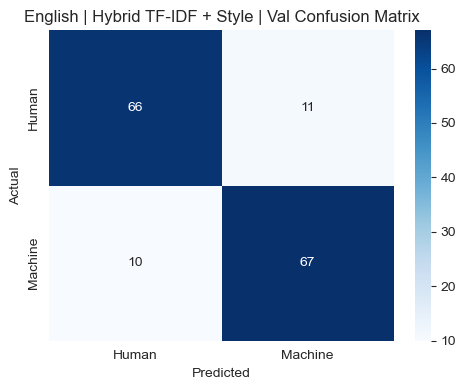


[English] [Hybrid TF-IDF + Style] Test Accuracy: 0.8831
              precision    recall  f1-score   support

       Human       0.89      0.87      0.88        77
     Machine       0.87      0.90      0.88        77

    accuracy                           0.88       154
   macro avg       0.88      0.88      0.88       154
weighted avg       0.88      0.88      0.88       154


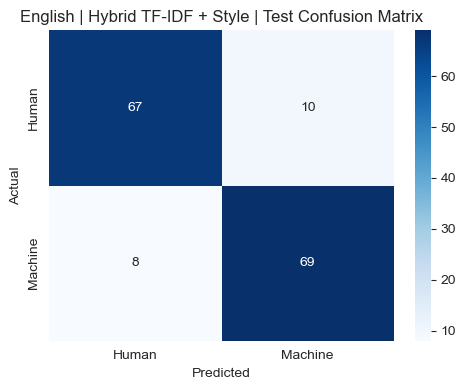

/Users/prayush/anaconda3/envs/Comp8420Assignment1/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [23:31:24] WARNING: /Users/ec2-user/croot/xgboost-split_1772031718290/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



[Nepali] [Hybrid TF-IDF + Style] Val Accuracy: 0.6146
              precision    recall  f1-score   support

       Human       0.61      0.62      0.61       102
     Machine       0.62      0.61      0.61       103

    accuracy                           0.61       205
   macro avg       0.61      0.61      0.61       205
weighted avg       0.61      0.61      0.61       205


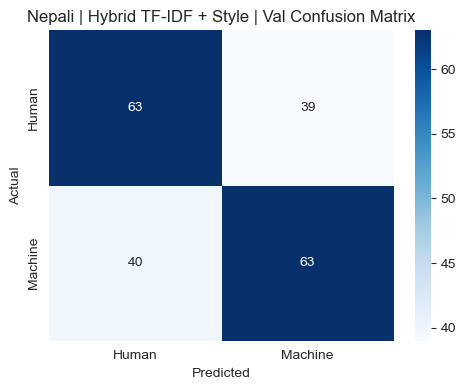


[Nepali] [Hybrid TF-IDF + Style] Test Accuracy: 0.6341
              precision    recall  f1-score   support

       Human       0.65      0.59      0.62       103
     Machine       0.62      0.68      0.65       102

    accuracy                           0.63       205
   macro avg       0.64      0.63      0.63       205
weighted avg       0.64      0.63      0.63       205


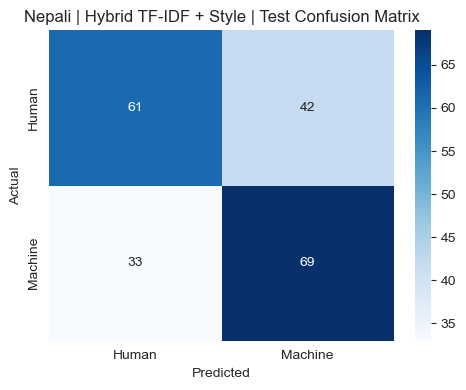

In [45]:
# English hybrid model
en_model_xgb = train_evaluate_hybrid_xgb(
    X_en_train, X_en_val, X_en_test,
    en_train, en_val, en_test,
    feature_name='Hybrid TF-IDF + Style', lang='English'
)

# Nepali hybrid model
np_model_xgb = train_evaluate_hybrid_xgb(
    X_np_train, X_np_val, X_np_test,
    np_train, np_val, np_test,
    feature_name='Hybrid TF-IDF + Style', lang='Nepali'
)

In experimenting with XGBoost, XGBoost achieved the highest accuracy (0.88) on TF-IDF and hybrid features because it can capture both content and style signals. TF-IDF identifies lexical patterns, like n-grams, that differ between human and machine-written text, while hybrid features encode writing style—sentence length, word repetition, vocabulary richness. 

Unlike Logistic Regression, which draws a straight line and treats features independently, XGBoost builds hundreds of decision trees, capturing complex non-linear interactions e.g., high vocabulary richness and long sentences together indicating machine text also its tree structure handles sparse TF-IDF efficiently and balances these with dense engineered features. 